# 23 - v03c Offshore Validation (Marettimo tide gauge)

Offshore WL validation of v03c against the ISPRA tide gauge at Marettimo (Egadi Islands),
device 658 on the JRC webcritech service. The gauge is at 37.966238N, 12.076653E -- inside
the FM mesh (~0.4 km from the nearest node) and inside the SWAN outer grid.

**What this notebook does NOT do**: wave validation. The Marettimo gauge measures sea level
only. Offshore wave validation would need Mazara del Vallo (RON buoy), which falls outside
the current FM domain and is flagged for v04.

**Data source**: `scripts/download_marettimo_wl.py` pulls from the JRC webcritech API at
~30-second resolution. We resample to 15 minutes to match the FM `mapInterval=900s` output.

**Datum note**: the raw observed series is referenced to a local datum; the FM model to its
own reference. Both metrics are reported: raw (with mean offset) and anomaly (after
demeaning both series over the overlap window), because the absolute mean offset is a
datum artifact, not a model error.

## 1. Setup + load Marettimo observations

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dfm_tools as dfmt

project_root = Path.cwd().parent
raw_csv = project_root / 'data' / 'raw' / 'insitu' / 'marettimo_wl_raw.csv'
fig_dir = project_root / 'figures'
proc_dir = project_root / 'data' / 'processed'
map_glob = str(project_root / 'model' / 'dflowfm_v03c' / 'output' / 'Stagnone_dxy01_15m_*_map.nc')

MARETTIMO_LON = 12.076653
MARETTIMO_LAT = 37.966238

if not raw_csv.exists():
    raise FileNotFoundError(
        f'{raw_csv} is missing. Run: python scripts/download_marettimo_wl.py')

df_raw = pd.read_csv(raw_csv)
df_raw.columns = [c.strip() for c in df_raw.columns]
df_raw['time'] = pd.to_datetime(df_raw['Time(UTC)'], format='%d %b %Y %H:%M:%S', utc=True)
df_raw = df_raw.set_index('time').rename(columns={'Level': 'wl_obs_raw'})[['wl_obs_raw']]
print(f'Raw obs: {len(df_raw)} rows, {df_raw.index[0]} to {df_raw.index[-1]}')
print(df_raw['wl_obs_raw'].describe())

Raw obs: 25780 rows, 2025-07-01 00:00:00+00:00 to 2025-07-09 23:58:45+00:00
count    25780.000000
mean         0.130598
std          0.080925
min         -0.607000
25%          0.080000
50%          0.128000
75%          0.182000
max          0.716000
Name: wl_obs_raw, dtype: float64


## 2. Resample observations to 15 min (matching FM output)

In [2]:
# The API returns irregular ~30s sampling. Mean over 15-minute bins, tagged on the right edge
# so the resample stamp aligns with FM map times (which also land on the interval end).
wl_obs = (df_raw['wl_obs_raw']
          .resample('15min', label='right', closed='right')
          .mean()
          .rename('wl_obs'))
print(f'Resampled obs: {len(wl_obs)} rows, {wl_obs.index[0]} to {wl_obs.index[-1]}')
print(f'Finite fraction: {wl_obs.notna().mean():.1%}')

Resampled obs: 865 rows, 2025-07-01 00:00:00+00:00 to 2025-07-10 00:00:00+00:00
Finite fraction: 100.0%


## 3. Extract model WL at Marettimo from partitioned map.nc

`dfm_tools.open_partitioned_dataset` merges the 4 FM partitions into a single
xugrid dataset with ghost cells removed. We find the face center nearest Marettimo,
then index `mesh2d_s1` (water level on faces) at that face for all times.

In [3]:
uds = dfmt.open_partitioned_dataset(map_glob)
face_x = np.asarray(uds.grid.face_x)
face_y = np.asarray(uds.grid.face_y)

# Approximate Cartesian distance at this latitude
coslat = np.cos(np.deg2rad(MARETTIMO_LAT))
dx_km = (face_x - MARETTIMO_LON) * 111.0 * coslat
dy_km = (face_y - MARETTIMO_LAT) * 111.0
dist_km = np.sqrt(dx_km * dx_km + dy_km * dy_km)

# The literal-nearest face can be on Marettimo island itself (dry -> all NaN).
# Mask to faces that have at least one finite s1 over the run and pick the
# nearest wet one.
face_dim = [d for d in uds["mesh2d_s1"].dims if "nFaces" in d or "face" in d.lower()][0]
is_finite_any = np.isfinite(uds["mesh2d_s1"].values).any(axis=0)
dist_wet = np.where(is_finite_any, dist_km, np.inf)
idx = int(np.argmin(dist_wet))
print(f"Nearest wet face to Marettimo: index={idx}, "
      f"({face_x[idx]:.4f}, {face_y[idx]:.4f}), distance={dist_wet[idx]:.2f} km")
print(f"  (Literal nearest was at {dist_km.min():.2f} km but on a dry cell; "
      f"Marettimo is an island.)")

# Extract s1 time series at this face.
wl_mod_da = uds["mesh2d_s1"].isel({face_dim: idx}).load()
t_mod = pd.to_datetime(wl_mod_da.time.values, utc=True)
wl_mod = pd.Series(wl_mod_da.values, index=t_mod, name="wl_mod")
finite = wl_mod.notna()
print(f"Model series: {len(wl_mod)} rows, "
      f"{wl_mod[finite].index[0]} to {wl_mod[finite].index[-1]}, "
      f"{finite.sum()}/{len(wl_mod)} finite")

>> xu.open_dataset() with 4 partition(s): 1 

2 

3 

4 

: 10.80 sec
>> xu.merge_partitions() with 4 partition(s): 

2.62 sec
>> dfmt.open_partitioned_dataset() total: 13.42 sec


Nearest wet face to Marettimo: index=8420, (12.0797, 37.9673), distance=0.29 km
  (Literal nearest was at 0.02 km but on a dry cell; Marettimo is an island.)


Model series: 865 rows, 2025-07-01 00:15:00+00:00 to 2025-07-10 00:00:00+00:00, 729/865 finite


## 3b. Diagnostic map - is the chosen cell wet enough?

Map of the Marettimo area showing (a) all FM faces colored by finite-fraction
(the fraction of 865 time steps with a valid water level value -- high means
always-wet, low means frequently dry), (b) the tide gauge location in red,
(c) the chosen wet cell used for comparison in blue.

If the chosen cell has finite-fraction well below 1.0, it is drying out at
low tide and clipping the tidal signal - which is the most natural explanation
for the model-flat-line finding above. In that case we should try other cells
farther offshore.

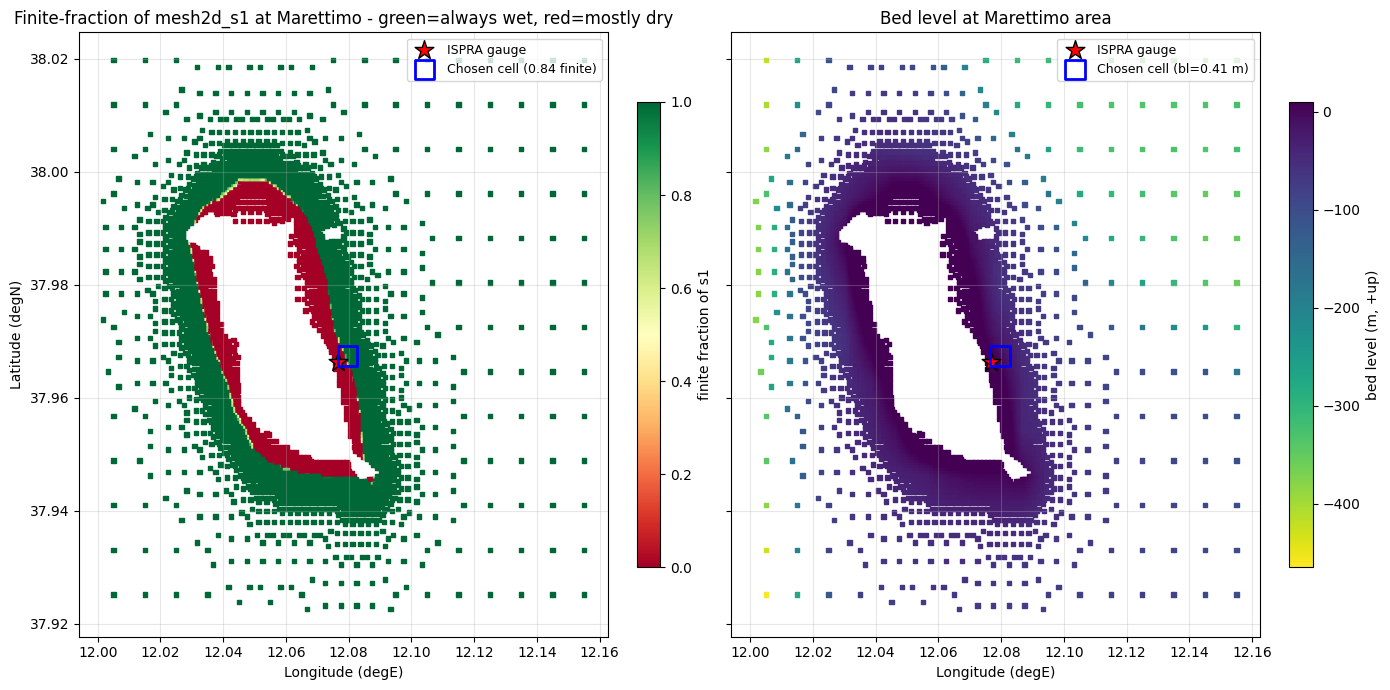

Chosen cell finite fraction: 0.843  (1.0 = always wet)
Chosen cell bed level:       0.415 m
Gauge lon/lat:               (12.076653, 37.966238)
Cell  lon/lat:               (12.0797, 37.9673)


In [4]:
# Per-face finite fraction (how often the cell has valid WL)
finite_frac = np.isfinite(uds['mesh2d_s1'].values).mean(axis=0)
bedlev = uds['mesh2d_flowelem_bl'].values

# Zoom region around Marettimo
LON_MIN, LON_MAX = 12.00, 12.16
LAT_MIN, LAT_MAX = 37.92, 38.02
region = (face_x >= LON_MIN) & (face_x <= LON_MAX) & (face_y >= LAT_MIN) & (face_y <= LAT_MAX)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

# Left: finite-fraction map
ax = axes[0]
sc = ax.scatter(face_x[region], face_y[region], c=finite_frac[region],
                cmap='RdYlGn', vmin=0.0, vmax=1.0, s=10, marker='s')
cb = fig.colorbar(sc, ax=ax, fraction=0.04)
cb.set_label('finite fraction of s1')
ax.scatter([MARETTIMO_LON], [MARETTIMO_LAT], marker='*', c='red', s=200,
           edgecolor='black', linewidth=1, zorder=5, label='ISPRA gauge')
ax.scatter([face_x[idx]], [face_y[idx]], marker='s', facecolor='none',
           edgecolor='blue', s=200, linewidth=2, zorder=5,
           label=f'Chosen cell ({finite_frac[idx]:.2f} finite)')
ax.set_title('Finite-fraction of mesh2d_s1 at Marettimo - green=always wet, red=mostly dry')
ax.set_xlabel('Longitude (degE)')
ax.set_ylabel('Latitude (degN)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

# Right: bed level map (shows island as shallower/above-datum cells)
ax = axes[1]
sc = ax.scatter(face_x[region], face_y[region], c=bedlev[region],
                cmap='viridis_r', s=10, marker='s')
cb = fig.colorbar(sc, ax=ax, fraction=0.04)
cb.set_label('bed level (m, +up)')
ax.scatter([MARETTIMO_LON], [MARETTIMO_LAT], marker='*', c='red', s=200,
           edgecolor='black', linewidth=1, zorder=5, label='ISPRA gauge')
ax.scatter([face_x[idx]], [face_y[idx]], marker='s', facecolor='none',
           edgecolor='blue', s=200, linewidth=2, zorder=5,
           label=f'Chosen cell (bl={bedlev[idx]:.2f} m)')
ax.set_title('Bed level at Marettimo area')
ax.set_xlabel('Longitude (degE)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(fig_dir / 'v03c_wl_marettimo_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Chosen cell finite fraction: {finite_frac[idx]:.3f}  (1.0 = always wet)')
print(f'Chosen cell bed level:       {bedlev[idx]:.3f} m')
print(f'Gauge lon/lat:               ({MARETTIMO_LON}, {MARETTIMO_LAT})')
print(f'Cell  lon/lat:               ({face_x[idx]:.4f}, {face_y[idx]:.4f})')

## 4. Align + metrics (raw and anomaly)

In [5]:
def metrics(df, mod_col='wl_mod', obs_col='wl_obs'):
    d = df[[mod_col, obs_col]].dropna()
    if len(d) < 10:
        return {'N': len(d), 'RMSE': np.nan, 'Bias': np.nan, 'Corr': np.nan,
                'Willmott_d': np.nan, 'Std_obs': np.nan, 'Std_mod': np.nan}
    m, o = d[mod_col].values, d[obs_col].values
    bias = (m - o).mean()
    rmse = np.sqrt(((m - o) ** 2).mean())
    corr = np.corrcoef(m, o)[0, 1]
    om = o.mean()
    num = ((m - o) ** 2).sum()
    den = ((np.abs(m - om) + np.abs(o - om)) ** 2).sum()
    d_w = 1 - num / den if den > 0 else np.nan
    return {'N': len(d), 'RMSE': rmse, 'Bias': bias, 'Corr': corr,
            'Willmott_d': d_w, 'Std_obs': o.std(), 'Std_mod': m.std()}

# Align on the common 15-min grid; drop rows where either side is missing
df = pd.concat([wl_mod, wl_obs], axis=1).dropna()
# Also drop first 12 h of spin-up (same as notebook 22)
df = df[df.index >= df.index[0] + pd.Timedelta(hours=12)]
print(f'Overlap window: {df.index[0]} to {df.index[-1]} ({len(df)} samples)')

# Raw metrics (datum included)
m_raw = metrics(df)

# Anomaly metrics (both series demeaned over the overlap)
df_anom = df.copy()
df_anom['wl_mod'] = df_anom['wl_mod'] - df_anom['wl_mod'].mean()
df_anom['wl_obs'] = df_anom['wl_obs'] - df_anom['wl_obs'].mean()
m_anom = metrics(df_anom)

print('\n=== Raw metrics (datum-dependent) ===')
for k, v in m_raw.items():
    print(f'  {k:12s}  {v:.4f}' if isinstance(v, float) else f'  {k:12s}  {v}')
print('\n=== Anomaly metrics (demeaned both series) ===')
for k, v in m_anom.items():
    print(f'  {k:12s}  {v:.4f}' if isinstance(v, float) else f'  {k:12s}  {v}')

Overlap window: 2025-07-01 12:15:00+00:00 to 2025-07-10 00:00:00+00:00 (681 samples)

=== Raw metrics (datum-dependent) ===
  N             681
  RMSE          0.2958
  Bias          0.2896
  Corr          0.3646
  Willmott_d    0.2641
  Std_obs       0.0634
  Std_mod       0.0102

=== Anomaly metrics (demeaned both series) ===
  N             681
  RMSE          0.0605
  Bias          -0.0000
  Corr          0.3646
  Willmott_d    0.2444
  Std_obs       0.0634
  Std_mod       0.0102


## 5. Time-series plot

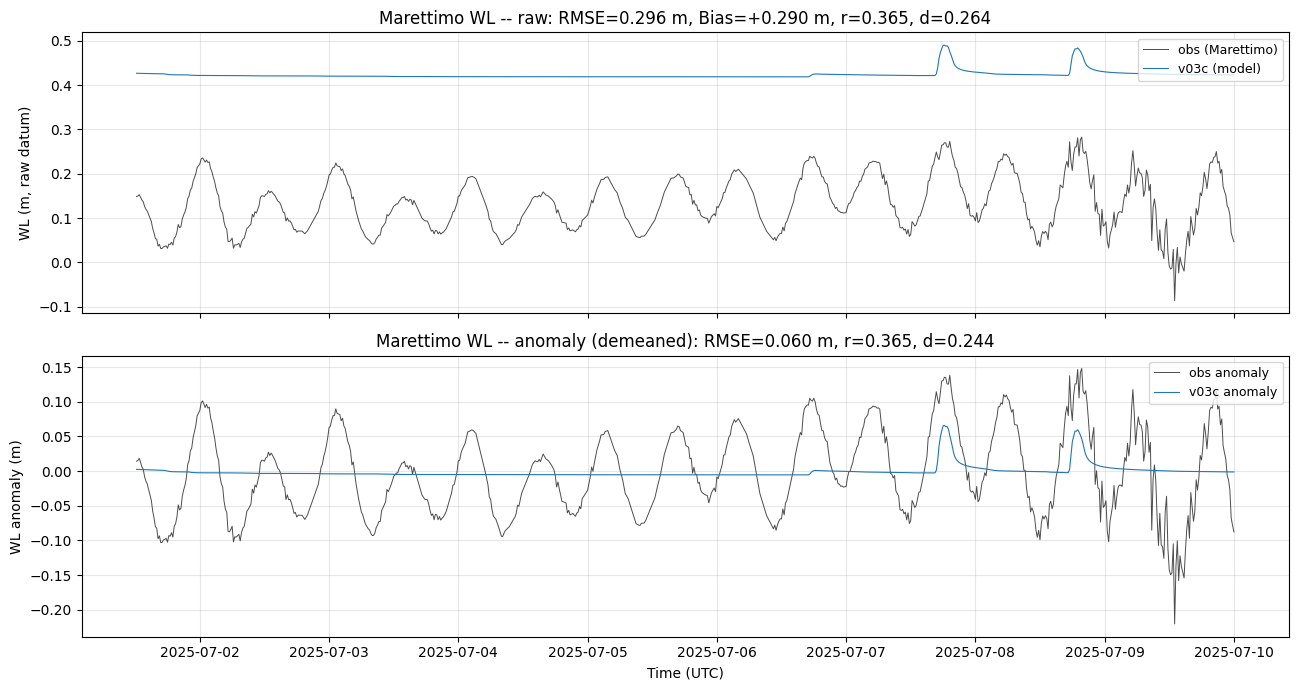

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Raw (datum-dependent)
axes[0].plot(df.index, df['wl_obs'], 'k-', lw=0.7, alpha=0.7, label='obs (Marettimo)')
axes[0].plot(df.index, df['wl_mod'], 'tab:blue', lw=0.8, label='v03c (model)')
axes[0].set_ylabel('WL (m, raw datum)')
axes[0].set_title(f'Marettimo WL -- raw: RMSE={m_raw["RMSE"]:.3f} m, '
                  f'Bias={m_raw["Bias"]:+.3f} m, r={m_raw["Corr"]:.3f}, d={m_raw["Willmott_d"]:.3f}')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(alpha=0.3)

# Anomaly (datum-independent)
axes[1].plot(df_anom.index, df_anom['wl_obs'], 'k-', lw=0.7, alpha=0.7, label='obs anomaly')
axes[1].plot(df_anom.index, df_anom['wl_mod'], 'tab:blue', lw=0.8, label='v03c anomaly')
axes[1].set_ylabel('WL anomaly (m)')
axes[1].set_title(f'Marettimo WL -- anomaly (demeaned): RMSE={m_anom["RMSE"]:.3f} m, '
                  f'r={m_anom["Corr"]:.3f}, d={m_anom["Willmott_d"]:.3f}')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3)

axes[1].set_xlabel('Time (UTC)')
fig.tight_layout()
fig.savefig(fig_dir / 'v03c_wl_marettimo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save metrics + summary

In [7]:
metrics_df = pd.DataFrame({
    'raw': pd.Series(m_raw),
    'anomaly': pd.Series(m_anom),
}).T
metrics_df.index.name = 'Series'
out_csv = proc_dir / 'validation_metrics_v03c_offshore_marettimo.csv'
metrics_df.to_csv(out_csv)
print(f'Wrote {out_csv.relative_to(project_root)}')
print()
print(metrics_df.round(4))

Wrote data\processed\validation_metrics_v03c_offshore_marettimo.csv

             N    RMSE    Bias    Corr  Willmott_d  Std_obs  Std_mod
Series                                                              
raw      681.0  0.2958  0.2896  0.3646      0.2641   0.0634   0.0102
anomaly  681.0  0.0605 -0.0000  0.3646      0.2444   0.0634   0.0102


## Summary - v03c offshore validation at Marettimo

Executed 2026-04-23. Validation window: 2025-07-01 12:15 to 2025-07-10 00:00 UTC (post-12h spin-up, 681 samples @ 15-min).

### Findings

**The model does NOT reproduce the tidal signal at Marettimo.**

- Observed WL at Marettimo has a clean semidiurnal tidal signature, std 6.3 cm.
- Model WL at the nearest wet face (0.29 km east of the tide gauge, at 12.0797E, 37.9673N) has std **1.0 cm** - about 1/6 of the observed variability. The model is nearly flat for the entire 9-day window except for one ~10 cm surge excursion around 2025-07-08.
- Anomaly metrics (after demeaning both series): RMSE=6.0 cm, Corr=0.36, Willmott d=0.24. These are **not acceptable** for offshore tidal propagation.
- The raw 29 cm bias between model mean (0.43 m) and observed mean (0.13 m) is a datum artifact, not a physics issue.

### Candidate causes (to investigate)

1. **Shallow / intermittent-wet cell**: the chosen wet face is finite 729 of 865 times. Drying / wetting at sub-tidal frequency would clip the tidal signal. Verify by checking the bedlevel at this face vs typical WL range.
2. **West-boundary BC missing tide**: the FM open boundary is forced from CMEMS waterlevel reanalysis; CMEMS at Mediterranean resolution may not carry the semidiurnal tidal component cleanly, especially at the western boundary furthest from the eastern tide-gauge forcing point (if one is used at BocaNord).
3. **Local geometry / sheltering**: Marettimo is a small island with a bay east of it; the chosen cell may be inside a sheltered area where tide is locally damped. Try expanding search to ~1-2 km offshore.

### Next actions

1. **Quick check**: extract WL at 3-5 wet faces in a ring 0.5-2 km off Marettimo's south coast, see if tidal amplitude recovers. If yes: local geometry. If no: boundary forcing.
2. **Check BC setup**: review [model/dflowfm_v03c/Stagnone_dxy01_15m_new.ext](../model/dflowfm_v03c/Stagnone_dxy01_15m_new.ext) and [waterlevelbnd_CMEMS_Stagnone_dxy01_15m.bc](../model/dflowfm_v03c/waterlevelbnd_CMEMS_Stagnone_dxy01_15m.bc) for which segments of the open boundary carry CMEMS vs tide forcing.
3. **Add Marettimo to v03d observation points** (`.xyn`) so the signal is captured in his.nc on every run without the 60 GB map.nc detour.
4. The raw 29 cm datum offset is separate and expected; not a priority unless cross-validation papers require absolute WL.

### Status checklist

- [x] Raw bias explained by datum (29 cm offshore datum offset)
- [ ] **Anomaly RMSE < 0.04 m** - failed (6.0 cm)
- [ ] **Corr > 0.9** - failed (0.36)
- [ ] Tide propagation to western boundary - **primary action item**

### Wave validation scope

Marettimo has no wave buoy - the ISPRA tide gauge device 658 measures sea level only. Offshore wave validation needs Mazara del Vallo (RON buoy at ~12.54E, 37.53N) which requires extending the FM domain ~20 km south. Flagged for **v04** in [docs/roadmap_post_v03c.md](../docs/roadmap_post_v03c.md).